In [49]:
"""
Automatically reloads libraries and utilities every time a cell is run
"""
%load_ext autoreload
%autoreload 2

The autoreload extension is already loaded. To reload it, use:
  %reload_ext autoreload


In [50]:
import sys
from pathlib import Path

ROOT = Path.cwd().resolve().parent
if str(ROOT) not in sys.path:
    sys.path.insert(0, str(ROOT))

from utils.PSF_helpers import *
from utils.Plot_helpers import *
from utils.Zernike_helpers import *
from utils.Booth_helpers import *
from utils.Phase_diversity_helpers_cupy import *

In [51]:
#minor style things to make the figures look nice
plt.style.use("bmh")
plt.rcParams["figure.figsize"] = [548 / 72, 390 / 72]
plt.rcParams["font.size"] = 12
plt.rcParams['text.usetex'] = True
plt.rcParams["figure.dpi"] = 300
import os
os.environ["PATH"] += os.pathsep + "/Library/TeX/texbin"

In [71]:
N_order = 1             # 3 for 3P, 2 for 2P
lambd = 1.3e-3            # Wavelength [mm]
n = 1.333                  # Refractive index
k = 2*n*np.pi/lambd        # Wavenumber
num_apt = 1.05            # Numerical aperture
focal = 7.2                    # Focal length of objective (Olympus) [mm]
mag = np.nan                   # Magnification rate from input to objective
w_0 = np.nan                 # mm
alpha = np.arcsin(num_apt / n)

#10 microns
L_ffp = 0.1
#512 x 512
grid_ffp = 320
grid = Centered_Square_Grid(L_ffp, grid_ffp, 0)
#CONJUGATE BFP LENGTH
grid_bfp = grid_ffp
L_bfp = (lambd * focal * grid_bfp) / L_ffp
microscope = Microscope(N_order, lambd, n, num_apt, focal, mag, w_0, L_bfp, grid_bfp)
x, y = grid.get_xy()
x_bfp = x * (L_bfp/ L_ffp)
y_bfp = y * (L_bfp/ L_ffp)



In [72]:
from PIL import Image 
f = np.flip(np.mean(np.asarray(Image.open("diego_headshot.png")), axis = 2))

In [88]:
rng = np.random.default_rng(15)
true_aberration = generate_johnson_aberration(3.0, alpha, rng)
d = forward_image(microscope, f, true_aberration)

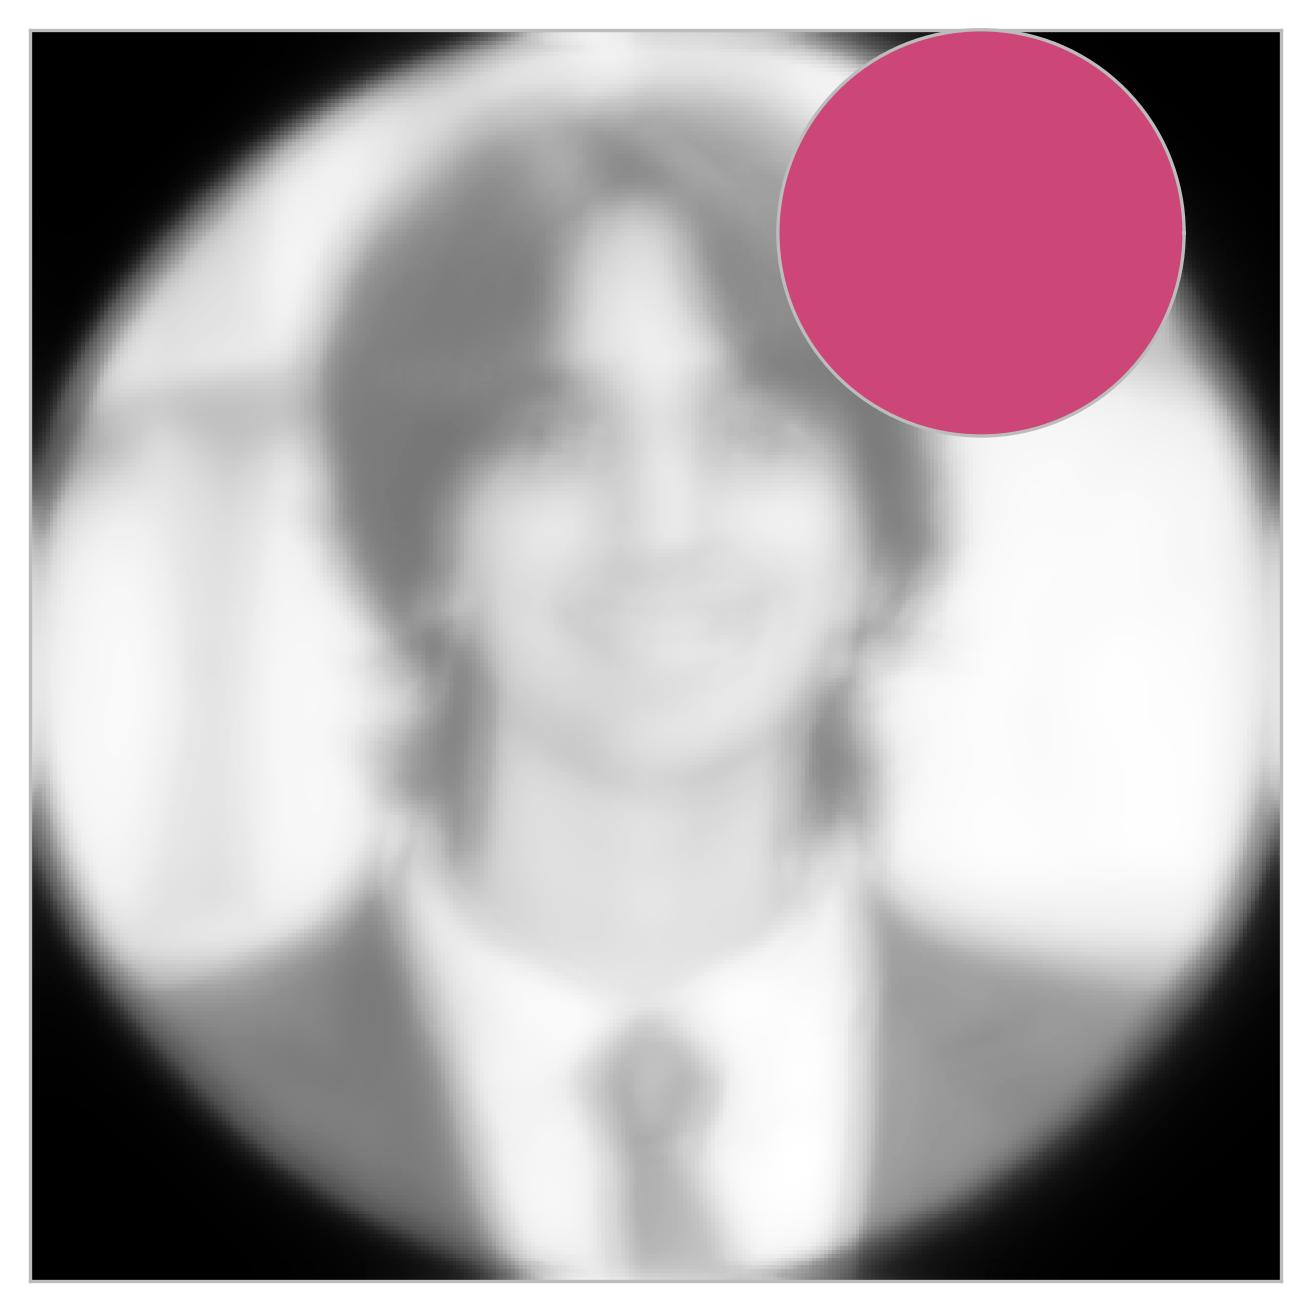

In [89]:
composite_plot_clean(x, y, d, EmptyAberration().construct_map(alpha), alpha)

In [91]:
bias_1 = true_aberration + Aberration([[0,4]], [0.5])
bias_2= true_aberration + Aberration([[0,4]], [-0.5])

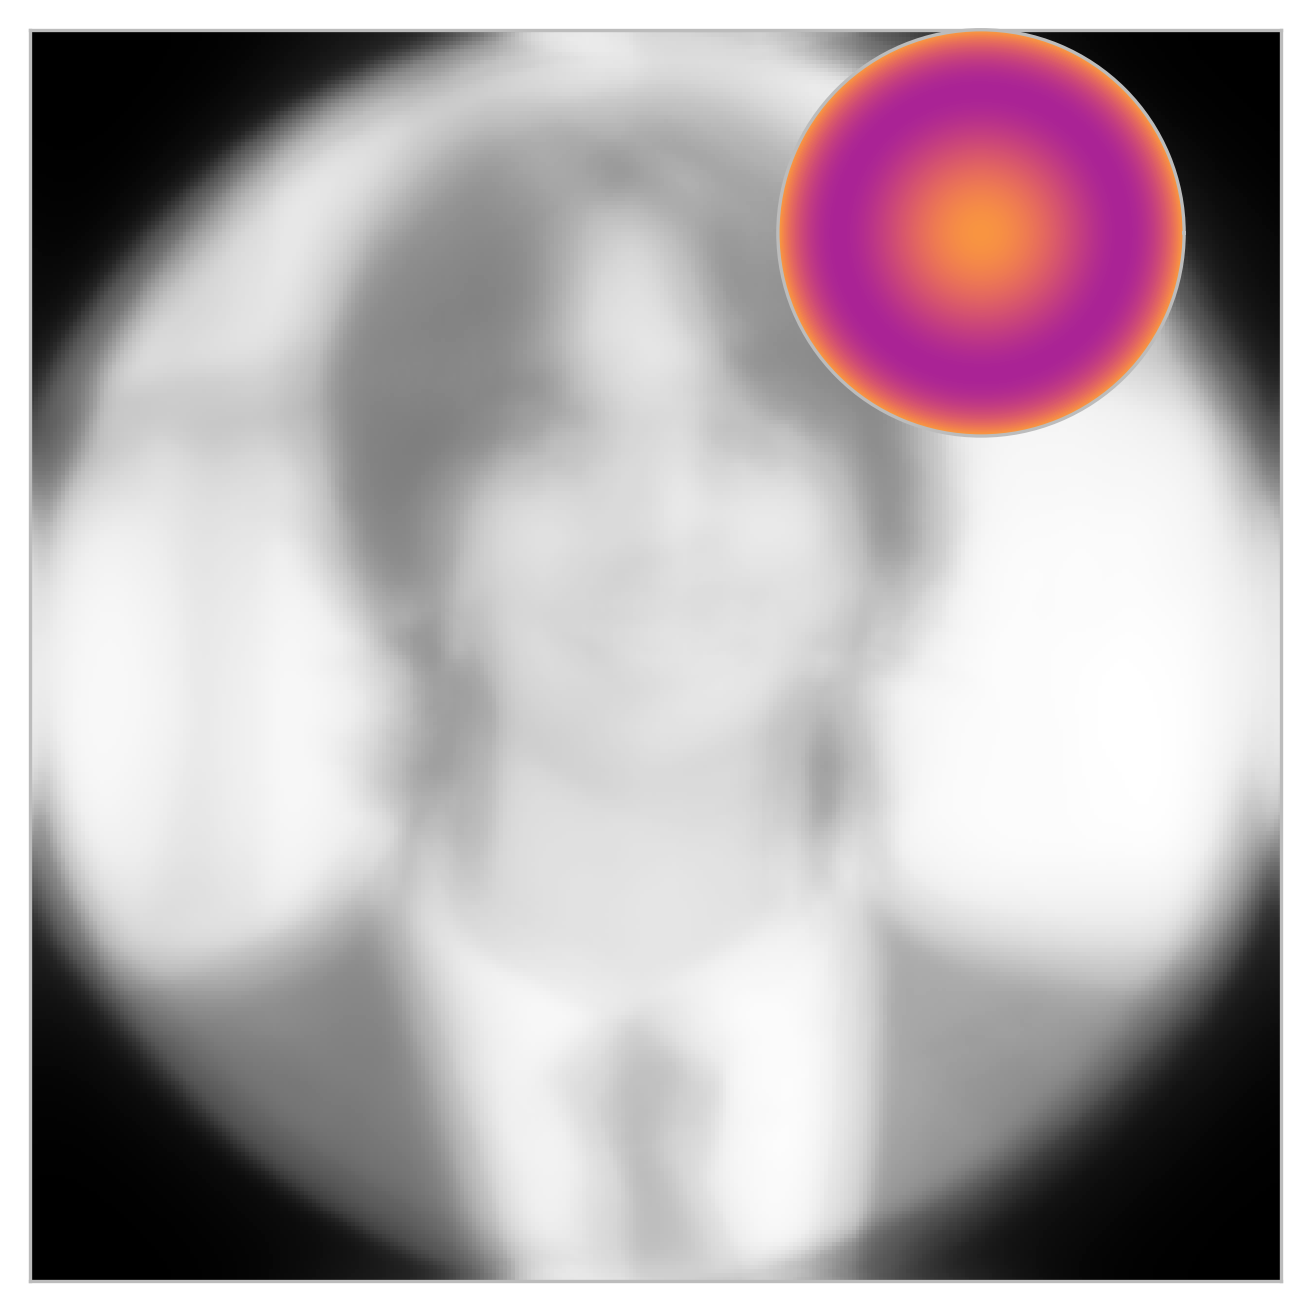

In [92]:
d_1 = forward_image(microscope, f, bias_1)
composite_plot_clean(x, y, d_1, Aberration([[0,4]], [0.5]).construct_map(alpha), alpha)

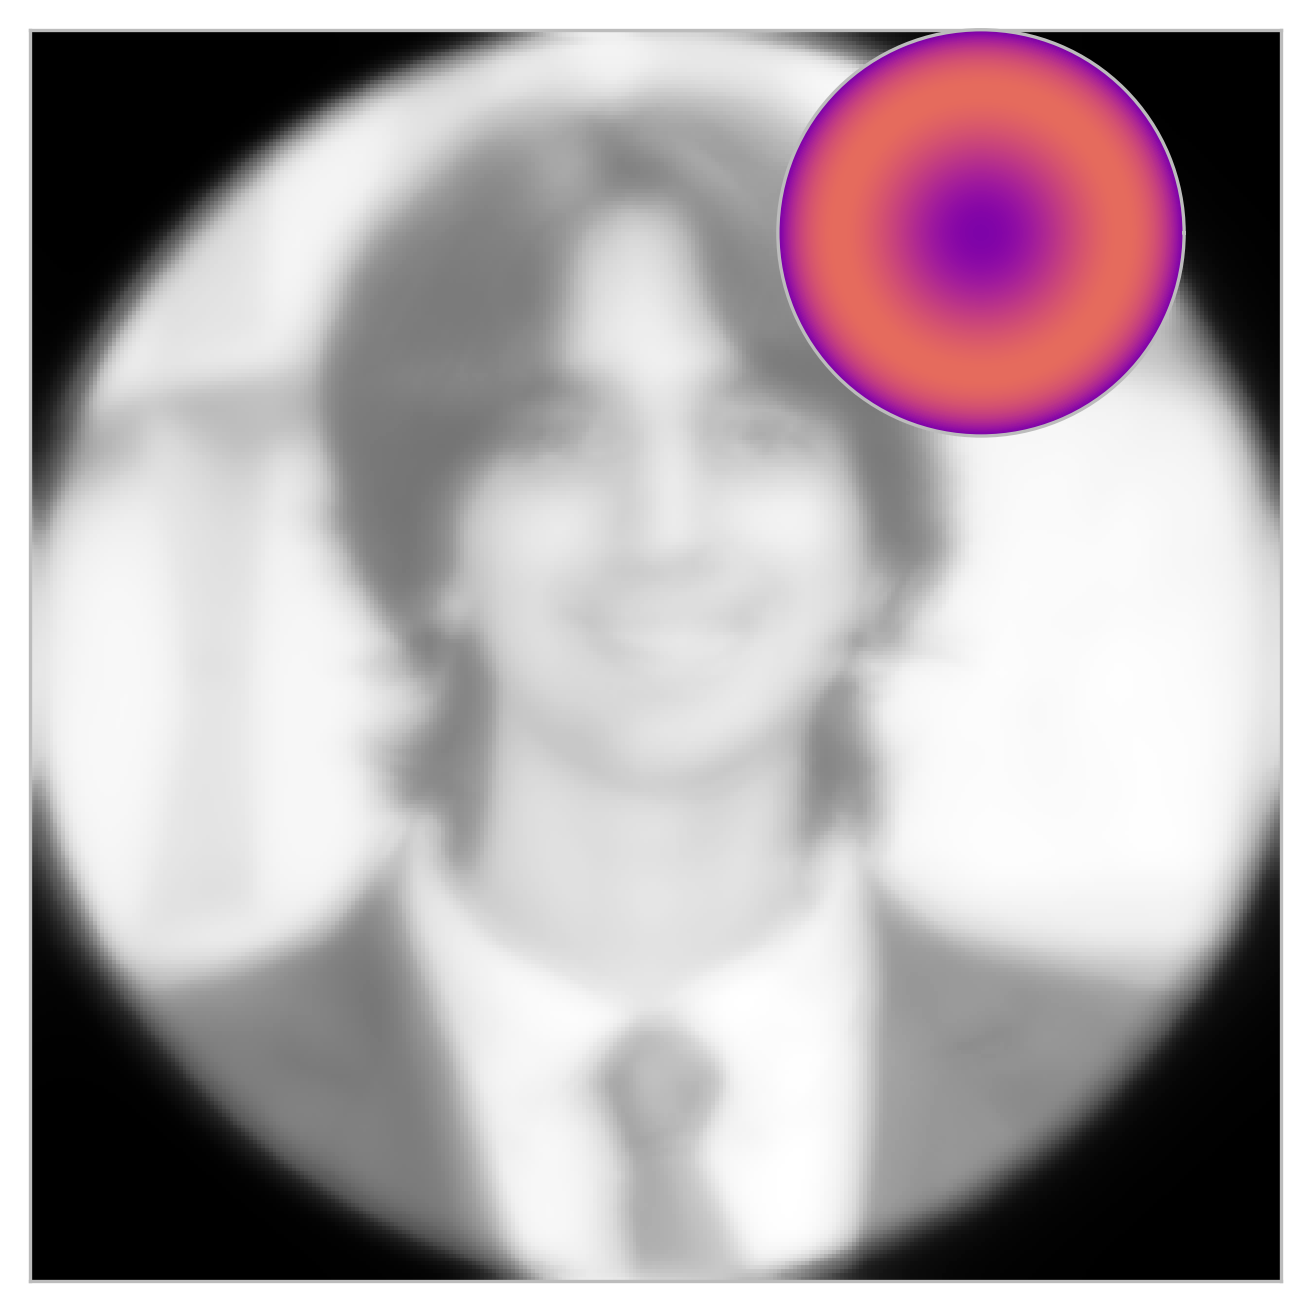

In [93]:
d_2 = forward_image(microscope, f, bias_2)
composite_plot_clean(x, y, d_2, Aberration([[0,4]], [-0.5]).construct_map(alpha), alpha)

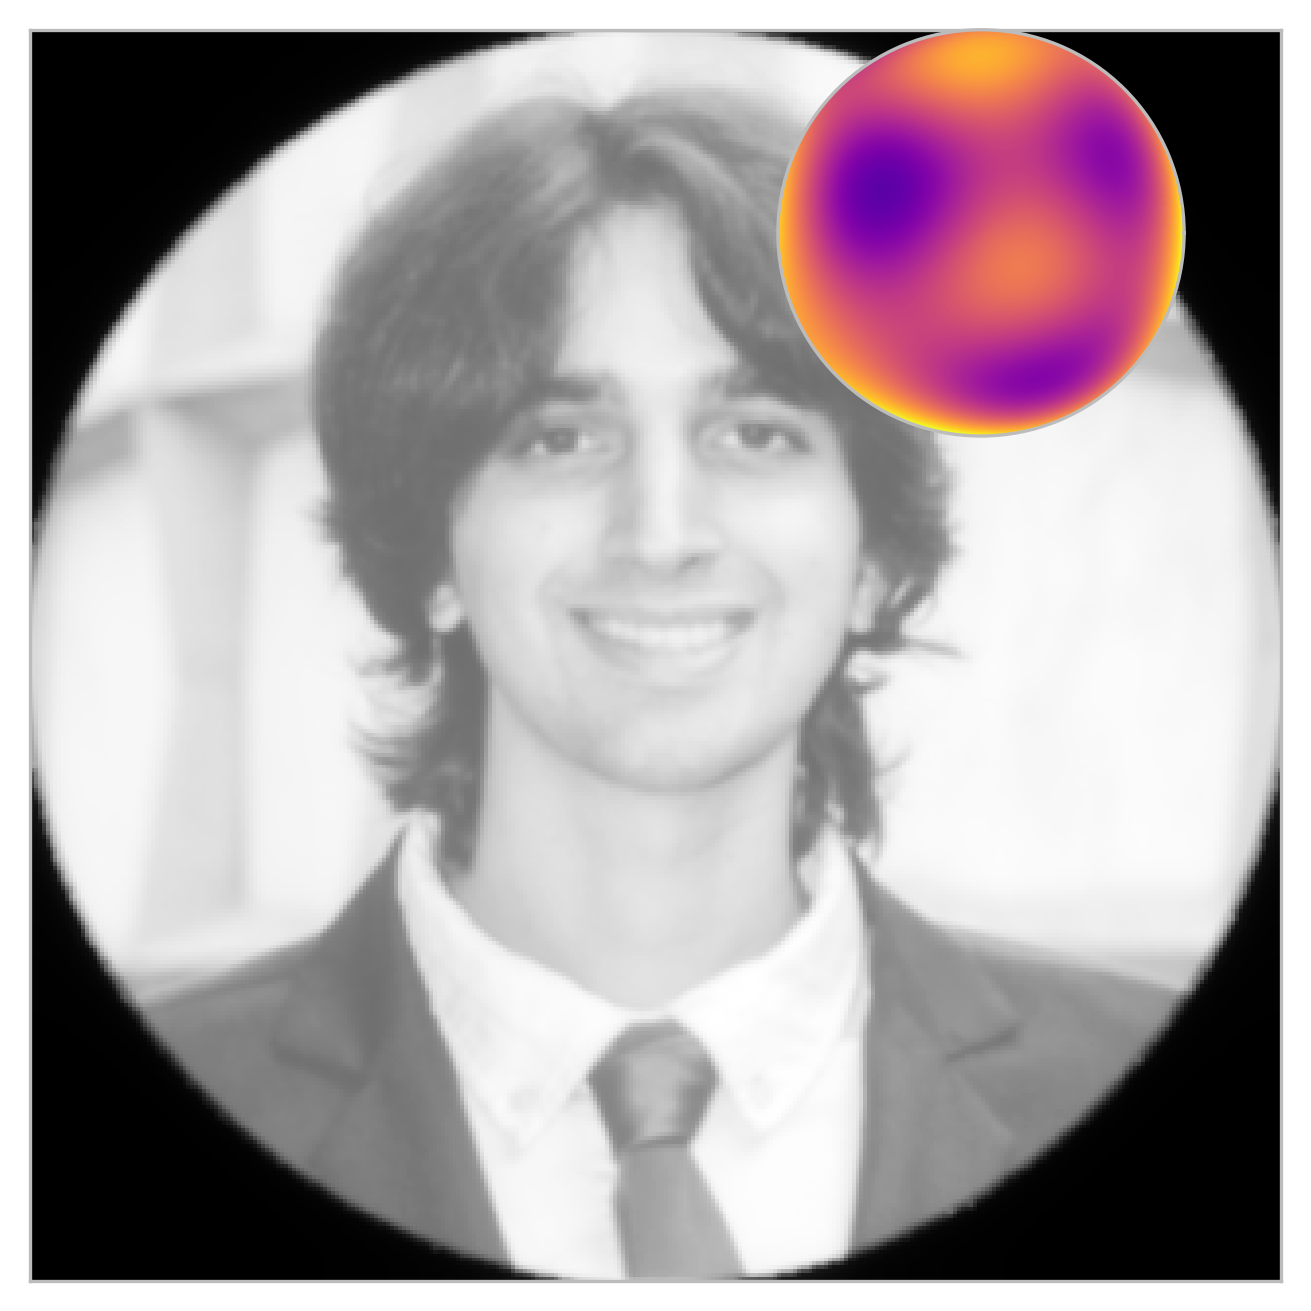

In [94]:
d = forward_image(microscope, f, EmptyAberration())
composite_plot_clean(x, y, d, true_aberration.construct_map(alpha), alpha)